<a href="https://colab.research.google.com/github/SebastiaoFigueredo/introducao_ia_projeto/blob/main/Diagnostico_doencas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd


In [ ]:
df = pd.read_csv('dados.csv')

In [ ]:
type(df)

pandas.core.frame.DataFrame

In [ ]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


<Axes: ylabel='Frequency'>

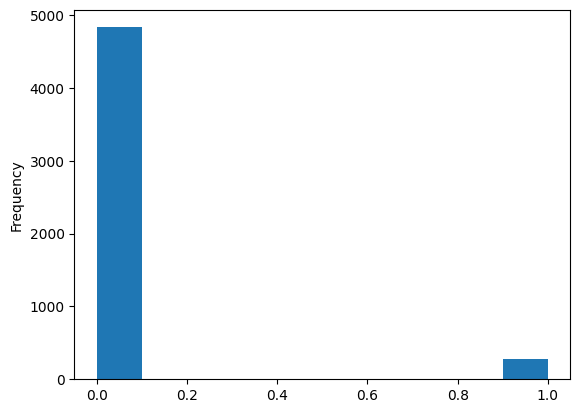

In [ ]:
from numpy import histogram
#analise exploratora

df['heart_disease'].plot(kind='hist')

In [ ]:
df.heart_disease.describe().astype(str)

,heart_disease
count,5110.0
mean,0.05401174168297456
std,0.22606298750336476
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,1.0


<Axes: ylabel='Frequency'>

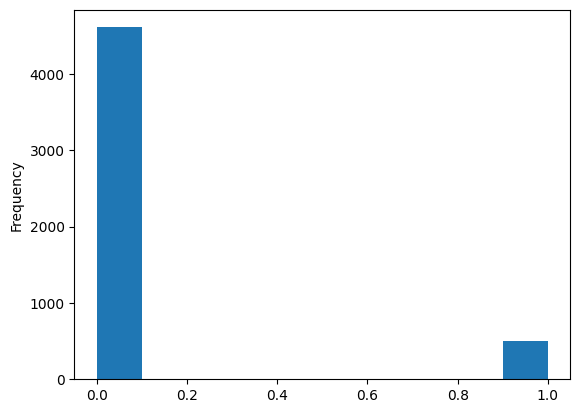

In [ ]:
df['hypertension'].plot(kind='hist')

In [ ]:
df.hypertension.describe().astype(str)

,hypertension
count,5110.0
mean,0.0974559686888454
std,0.29660667423378534
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,1.0


<Axes: >

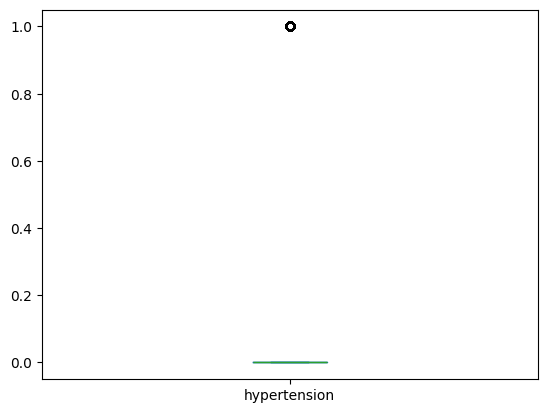

In [ ]:
df.hypertension.plot(kind='box')

outliers


In [ ]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


<Axes: xlabel='age', ylabel='heart_disease'>

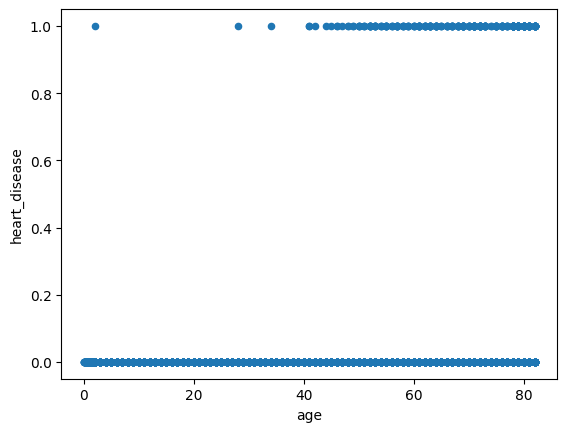

In [ ]:
df.plot(kind='scatter', x='age', y='heart_disease')

In [ ]:
import seaborn as sns

In [ ]:
correlacao = df.corr(numeric_only=True)

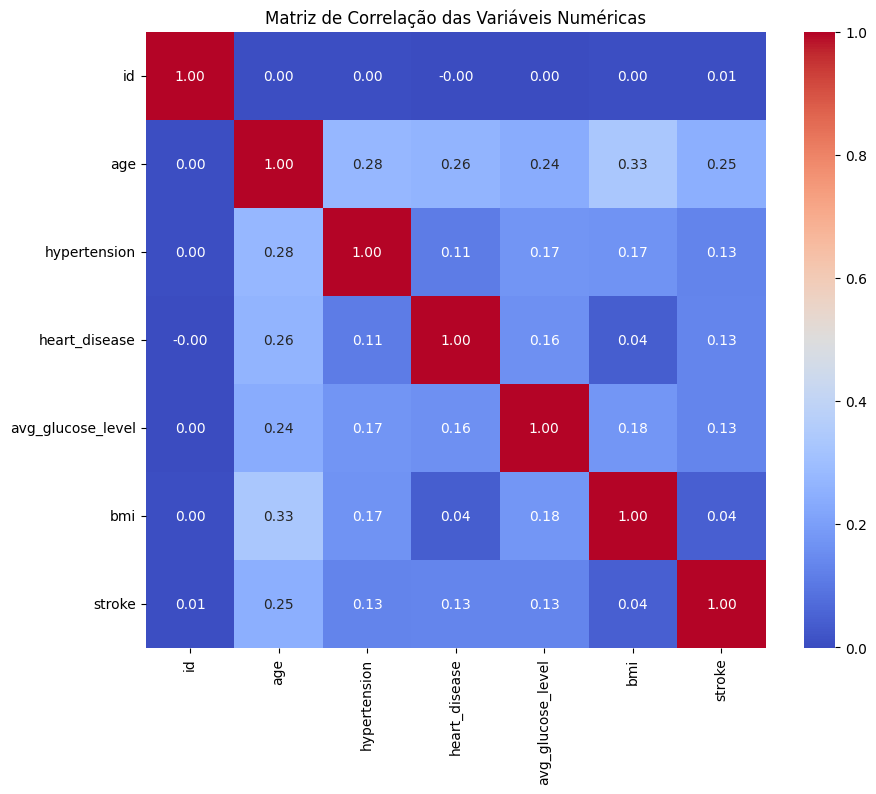

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.show()

In [ ]:
X = df.drop(columns=['heart_disease'])
y = df.heart_disease

In [ ]:
X

,id,gender,age,hypertension,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [ ]:
y

,heart_disease
0,1
1,0
2,1
3,0
4,0
...,...
5105,0
5106,0
5107,0
5108,0


In [ ]:
#Separaçao dos dados em treino e testes

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train

,id,gender,age,hypertension,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
802,4970,Male,79.00,0,Yes,Self-employed,Rural,112.64,28.5,formerly smoked,0
3927,56137,Female,62.00,0,Yes,Private,Urban,88.32,36.3,Unknown,0
2337,54590,Female,21.00,0,No,Private,Rural,59.52,33.7,never smoked,0
3910,36548,Male,31.00,0,Yes,Govt_job,Urban,65.70,30.4,formerly smoked,0
1886,61171,Female,31.00,0,No,Private,Rural,59.63,19.9,never smoked,0
...,...,...,...,...,...,...,...,...,...,...,...
4426,13846,Male,43.00,0,Yes,Govt_job,Rural,88.00,30.6,never smoked,0
466,1307,Female,61.00,1,Yes,Private,Rural,170.05,60.2,smokes,0
3092,31481,Female,1.16,0,No,children,Urban,97.28,17.8,Unknown,0
3772,61827,Male,80.00,0,Yes,Self-employed,Rural,196.08,31.0,formerly smoked,0


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
from sklearn.impute import SimpleImputer

# Apply one-hot encoding to categorical features in X_train and X_test
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Align columns of X_test_encoded to match X_train_encoded
# This handles cases where X_test has categories not seen in X_train, or vice-versa
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# Impute missing values (e.g., in 'bmi' column) using the mean strategy
imputer = SimpleImputer(strategy='mean')
X_train_encoded_imputed = pd.DataFrame(imputer.fit_transform(X_train_encoded), columns=X_train_encoded.columns, index=X_train_encoded.index)
X_test_encoded_imputed = pd.DataFrame(imputer.transform(X_test_encoded), columns=X_test_encoded.columns, index=X_test_encoded.index)

model_1 = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
model_1.fit(X_train_encoded_imputed, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.linear_model import LogisticRegression

model_1 = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
model_1.fit(X_train_encoded_imputed, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
model_1.score(X_train_encoded_imputed, y_train)

0.9471624266144814

In [ ]:
model_1.intercept_

array([-6.93979638])

In [ ]:
model_1.coef_

array([[-2.39572710e-06,  7.70077534e-02,  1.14410809e-01,
         5.35363960e-03, -1.43753472e-02,  3.59212870e-01,
         8.38713749e-01, -5.32533885e-01, -1.15034558e-01,
        -1.52671237e-01, -4.68576880e-01, -2.36658768e+00,
        -1.26537505e-01, -1.41975396e-01, -5.89370192e-01,
         1.30482796e-01]])